<a href="https://colab.research.google.com/github/Bryan1093/ApendizajeAutomatico/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
from google.colab import drive
# Conectamos con nuestro Google Drive
drive.mount('/content/drive')
# Establezco una ruta absoluta a un directorio existente de mi Google Drive
BASE_FOLDER = "/content/drive/MyDrive/Colab Notebooks/AprendizajeAutomatico/"
# agregamos a las paths del sistema la del colab
sys.path.append(BASE_FOLDER)

Mounted at /content/drive


In [ ]:
!pip install pandas openpyxl

In [ ]:
import pandas as pd

In [ ]:
# Ajusta la ruta según la ubicación de tu archivo en Drive
ruta = 'drive/MyDrive/Colab Notebooks/AprendizajeAutomatico/Titanic/titanic.csv'
df = pd.read_csv(ruta)
print('Dataset: TITANIC')
# Numero de instancias
print(f'Numero de instancias: {df.shape[0]}')
# Numero de atributos
print(f'Numero de atributos: {df.shape[1]}')
# Nombre de los atributos
print(f'Nombre de los atributos: {df.columns}')
print(f'Tipos de datos: \n' + str(df.dtypes))



Dataset: TITANIC
Numero de instancias: 891
Numero de atributos: 12
Nombre de los atributos: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Tipos de datos: 
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
# Verificar valores nulos en el dataset
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Verificar si hay filas duplicadas
print(f"\nFilas duplicadas: {df.duplicated().sum()}")



Valores nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Filas duplicadas: 0


In [ ]:
# Calcular la frecuencia absoluta
frecuencia_absoluta = df['Pclass'].value_counts()
# Calcular la frecuencua relativa
frecuencia_relativa = df['Pclass'].value_counts(normalize=True)
print("Frecuencia Absoluta: ", frecuencia_absoluta)
print("Frecuencia Relativa: ", frecuencia_relativa)

import numpy as np
Sex , frecuencia = np.unique(df['Sex'], return_counts=True)
print(f'Sex: {Sex}')
print(f'frecuencia: {frecuencia}')

Frecuencia Absoluta:  Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Frecuencia Relativa:  Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64
Sex: ['female' 'male']
frecuencia: [314 577]


In [ ]:
# Calcular la frecuencia absoluta de 'Age' (sin contar NaN)
frecuencia_absoluta_age = df['Age'].value_counts().sort_index()
print("\nFrecuencia Absoluta de Age:")
print(frecuencia_absoluta_age)

# Calcular la frecuencia relativa de 'Age' (sin contar NaN)
frecuencia_relativa_age = df['Age'].value_counts(normalize=True).sort_index()
print("\nFrecuencia Relativa de Age:")
print(frecuencia_relativa_age)


Frecuencia Absoluta de Age:
Age
0.42     1
0.67     1
0.75     2
0.83     2
0.92     1
        ..
70.00    2
70.50    1
71.00    2
74.00    1
80.00    1
Name: count, Length: 88, dtype: int64

Frecuencia Relativa de Age:
Age
0.42     0.001401
0.67     0.001401
0.75     0.002801
0.83     0.002801
0.92     0.001401
           ...   
70.00    0.002801
70.50    0.001401
71.00    0.002801
74.00    0.001401
80.00    0.001401
Name: proportion, Length: 88, dtype: float64


In [ ]:
# Frecuencia cruzada entre Pclass y Survived
frecuencia_cruzada = pd.crosstab(df['Pclass'], df['Survived'])
print("Frecuencia Cruzada entre Pclass y Survived:\n", frecuencia_cruzada)


Frecuencia Cruzada entre Pclass y Survived:
 Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


In [ ]:
# Frecuencia cruzada entre Pclass, Sex y Survived
supervivencia = df.groupby(['Pclass', 'Sex'])['Survived'].mean()
print(supervivencia)

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64


In [ ]:
df_num = df.select_dtypes(include= ['float64', 'int64'])
# Calcular la media de cada atributo numerico
media_atributos = df_num.mean()
# Calcular la mediana de cada atributo numerico
median_atributos = df_num.median()
# Calcular la moda de cada atributo numerico
mode_values_specific = df.mode()
# Calcular la desviacion estandar de la columna especifica
mean_values_specific = df[['Age', 'Fare']].mean()
# Calcular la mediana de la columna especifica
median_values_specific = df[['Age', 'Fare']].median()
# Calcular la moda de la columna especifica
mode_values_specific = df[['Age', 'Fare']].mode()


In [ ]:
# Descricipn de los atributos de los datos Numerico
display(df_num.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

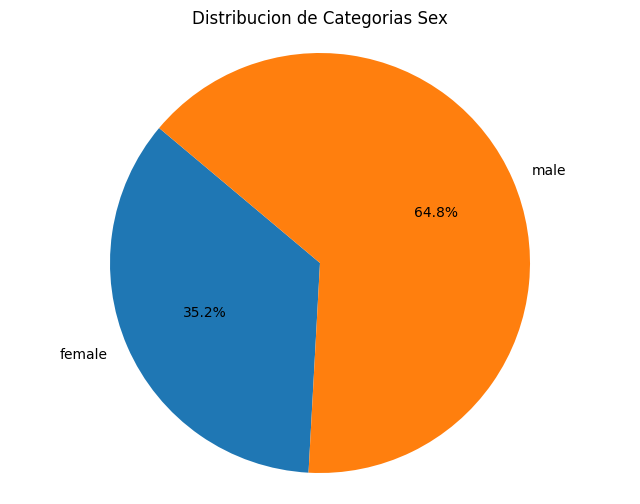

In [ ]:
# Crear el grafico de pastel
plt.figure(figsize=(8,6))
plt.pie(frecuencia, labels=Sex, autopct='%1.1f%%', startangle=140)
plt.title('Distribucion de Categorias Sex')
plt.axis('equal')
plt.show()

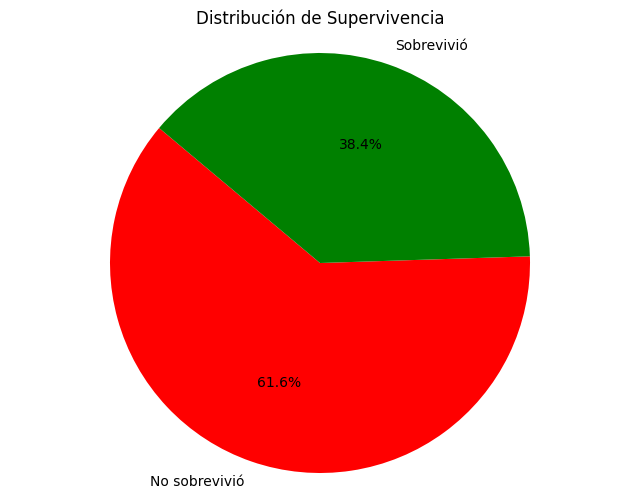

In [ ]:
# Calcular la frecuencia por supervivencia
supervivencia, frecuencia_supervivencia = np.unique(df['Survived'], return_counts=True)

# Crear el gráfico de pastel
plt.figure(figsize=(8, 6))
plt.pie(frecuencia_supervivencia, labels=['No sobrevivió', 'Sobrevivió'], autopct='%1.1f%%', startangle=140, colors=['red', 'green'])
plt.title('Distribución de Supervivencia')
plt.axis('equal')
plt.show()



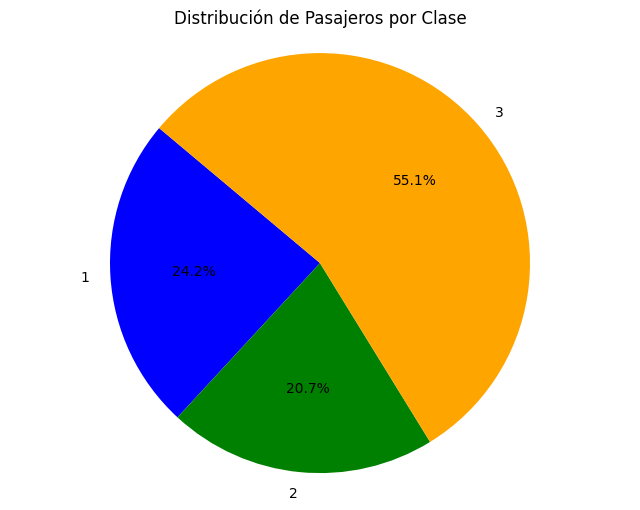

In [ ]:
# Calcular la frecuencia por clase de pasaje
clases, frecuencia_clases = np.unique(df['Pclass'], return_counts=True)

# Crear el gráfico de pastel
plt.figure(figsize=(8, 6))
plt.pie(frecuencia_clases, labels=clases, autopct='%1.1f%%', startangle=140, colors=['blue', 'green', 'orange'])
plt.title('Distribución de Pasajeros por Clase')
plt.axis('equal')  # Asegura que el gráfico sea circular
plt.show()



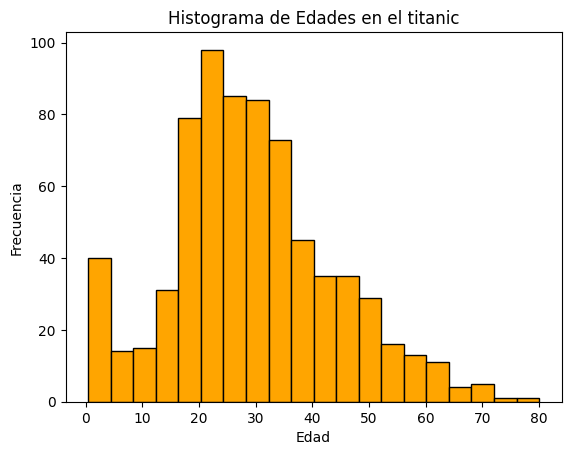

In [ ]:
plt.hist(df['Age'], bins=20, color= 'orange', edgecolor='black')
# Añadir titulos y etiquetas
plt.title('Histograma de Edades en el titanic')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
# Mostrar el grafico
plt.show()

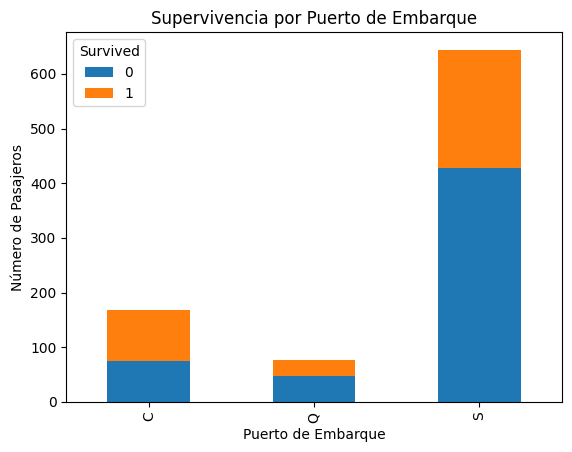

In [ ]:
# Gráfico de barras de supervivencia por puerto de embarque
supervivencia_por_puerto = pd.crosstab(df['Embarked'], df['Survived'])
supervivencia_por_puerto.plot(kind='bar', stacked=True)

plt.title('Supervivencia por Puerto de Embarque')
plt.xlabel('Puerto de Embarque')
plt.ylabel('Número de Pasajeros')
plt.show()


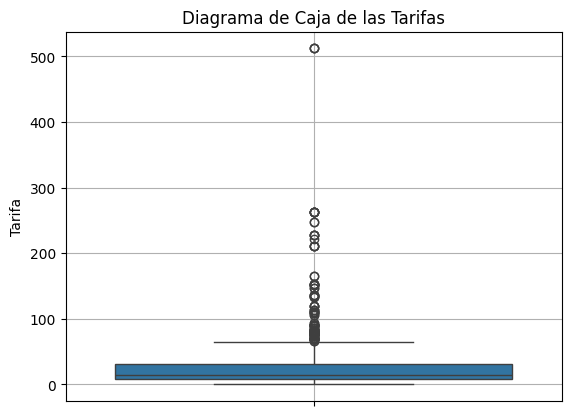

In [ ]:
# Crear un diagrama de caja de las tarifas (Fare)
sns.boxplot(data=df['Fare'])
plt.title('Diagrama de Caja de las Tarifas')
plt.ylabel('Tarifa')
plt.grid(True)  # Añadir una cuadrícula para mejor visualización
plt.show()


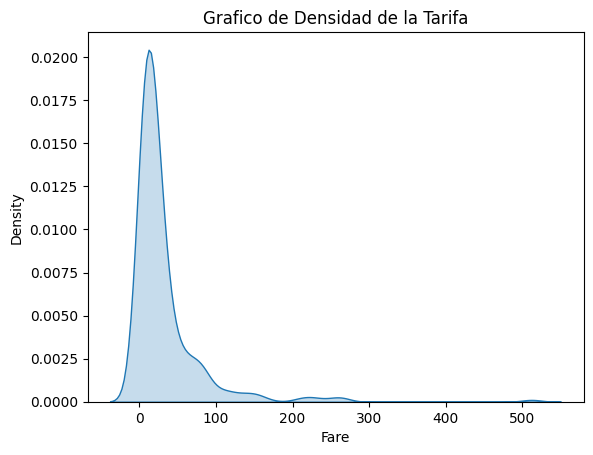

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df['Fare'], fill=True)
plt.title('Grafico de Densidad de la Tarifa')
plt.show()

In [ ]:
import seaborn as sns

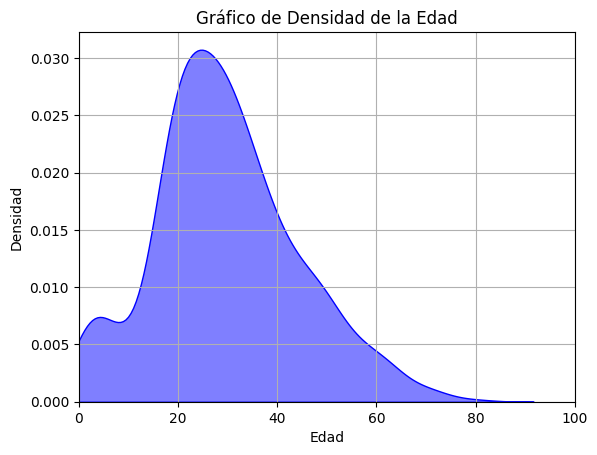

In [ ]:
# Crear un gráfico de densidad de la Edad
sns.kdeplot(data=df['Age'], fill=True, color='blue', alpha=0.5)
plt.title('Gráfico de Densidad de la Edad')
plt.xlabel('Edad')
plt.ylabel('Densidad')
plt.xlim(0, 100)  # Ajustar los límites del eje x según el rango de edad
plt.grid(True)     # Añadir una cuadrícula para mejor visualización
plt.show()

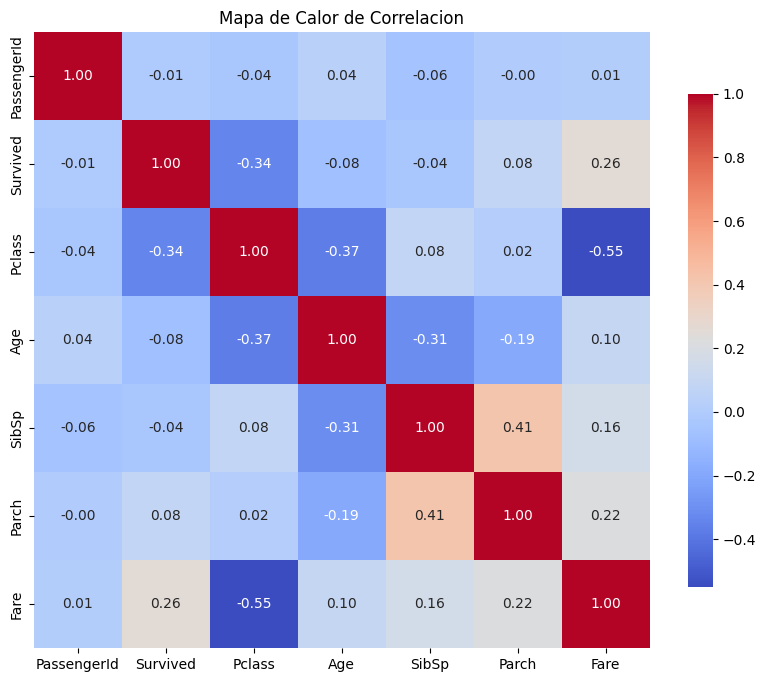

In [ ]:
# Filtrar solo los atributos numerico
df_num = df.select_dtypes(include='number')
# Calcular la matriz de correlacion
correlacion_matrix = df_num.corr()
# Crear el mapo de calor
plt.figure(figsize=(10,8))
sns.heatmap(correlacion_matrix, annot=True,  fmt='.2f', cmap='coolwarm',
            square= True, cbar_kws={"shrink": .8})
# Añadir titulos
plt.title('Mapa de Calor de Correlacion')
plt.show()
